# CLIP: Contrastive Language-Image Pre-training

## Learning Objectives

By the end of this notebook, you will understand:
- How **CLIP** connects vision and language in a unified embedding space
- The power of **zero-shot classification** using natural language
- **Dual encoder architecture**: image encoder + text encoder
- How **contrastive learning** aligns images and text
- Building a complete CLIP model from scratch
- Real-world applications: image search, text-to-image, multimodal AI

## The Journey

We'll build CLIP incrementally:

1. **Introduction** - Why CLIP revolutionized computer vision
2. **The Big Idea** - Vision meets language through contrastive learning
3. **Architecture** - Dual encoders + projection heads
4. **Contrastive Loss** - InfoNCE for multimodal learning
5. **Implementation** - Build CLIP from scratch
6. **Training** - Learn image-text alignment on MNIST
7. **Zero-Shot Classification** - Classify without task-specific training
8. **Embedding Space** - Visualize the learned multimodal space
9. **Applications** - Image search, compositionality, and beyond

**The Revolutionary Idea**: Train on image-text pairs from the internet, then classify any image using natural language descriptions!

## Part 1: Why CLIP Changed Everything

### The Traditional Computer Vision Pipeline

Before CLIP, image classification worked like this:

1. **Collect labeled data**: Manually label thousands of images (expensive!)
2. **Train a classifier**: Learn to map images → fixed set of classes
3. **Deploy**: Model only knows those specific classes
4. **New class?** → Collect more labels, retrain from scratch

**Problems**:
- Requires expensive labeled datasets
- Fixed to specific classes (can't generalize)
- No connection to language or human understanding

### The CLIP Revolution

CLIP (from OpenAI, 2021) changed the game:

1. **Train on image-text pairs**: 400M images with captions from the web (natural supervision!)
2. **Learn a shared embedding space**: Images and text live in the same space
3. **Zero-shot classification**: Describe classes in text, no retraining needed
4. **New class?** → Just write a text description!

**Key Insight**: Instead of learning "this is class 7", learn "this image matches the text 'a photo of a cat'".

### Real-World Impact

CLIP became the foundation for:
- **DALL-E 2, Stable Diffusion**: Text-to-image generation
- **GPT-4 Vision**: Multimodal understanding
- **Flamingo, LLaVA**: Vision-language models
- **Image search engines**: Search images using natural language

Let's build one to understand how it works!

## Part 2: Setup

In [1]:
# Standard imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

# Shared library
from aiml_notebooks import (
    get_device,
    set_seed,
    count_parameters,
    TrainingHistory,
    MNIST_MEAN,
    MNIST_STD,
    MNIST_CLASSES,
)

%load_ext autoreload
%autoreload 2

### Set random seed for reproducibility

In [2]:
set_seed(42)

### Configure device

In [3]:
device = get_device()
print(f"Using device: {device}")

Using MPS (Metal Performance Shaders) for GPU acceleration
Using device: mps


## Part 3: The CLIP Architecture

### Dual Encoder Design

CLIP has two parallel encoders that project images and text into a **shared embedding space**:

```
Image  → Image Encoder   → Image Projection  → Image Embedding (d-dim)
                                                      ↓
                                               [Cosine Similarity]
                                                      ↓
Text   → Text Encoder    → Text Projection   → Text Embedding (d-dim)
```

### Components

1. **Image Encoder**: ResNet or Vision Transformer (ViT)
   - Extracts visual features from images
   - Outputs a feature vector (e.g., 512-dim)

2. **Text Encoder**: Transformer
   - Processes text sequences (captions, descriptions)
   - Outputs a text feature vector (same dimension)

3. **Projection Heads**: Linear layers
   - Projects image and text features to a shared embedding space
   - Typically 512 or 1024 dimensions

4. **Contrastive Loss**: InfoNCE
   - Matches corresponding image-text pairs
   - Pushes apart non-matching pairs

### Key Insight

**Matching pairs** (image of a cat + "a photo of a cat") should have **high cosine similarity**.

**Non-matching pairs** (image of a cat + "a photo of a dog") should have **low similarity**.

Let's visualize this concept!

### Visualizing the shared embedding space

/var/folders/wz/x29jb7_x5rdc_5dcjr4qnhg00000gn/T/ipykernel_41254/2507049623.py:47: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/wz/x29jb7_x5rdc_5dcjr4qnhg00000gn/T/ipykernel_41254/2507049623.py:47: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


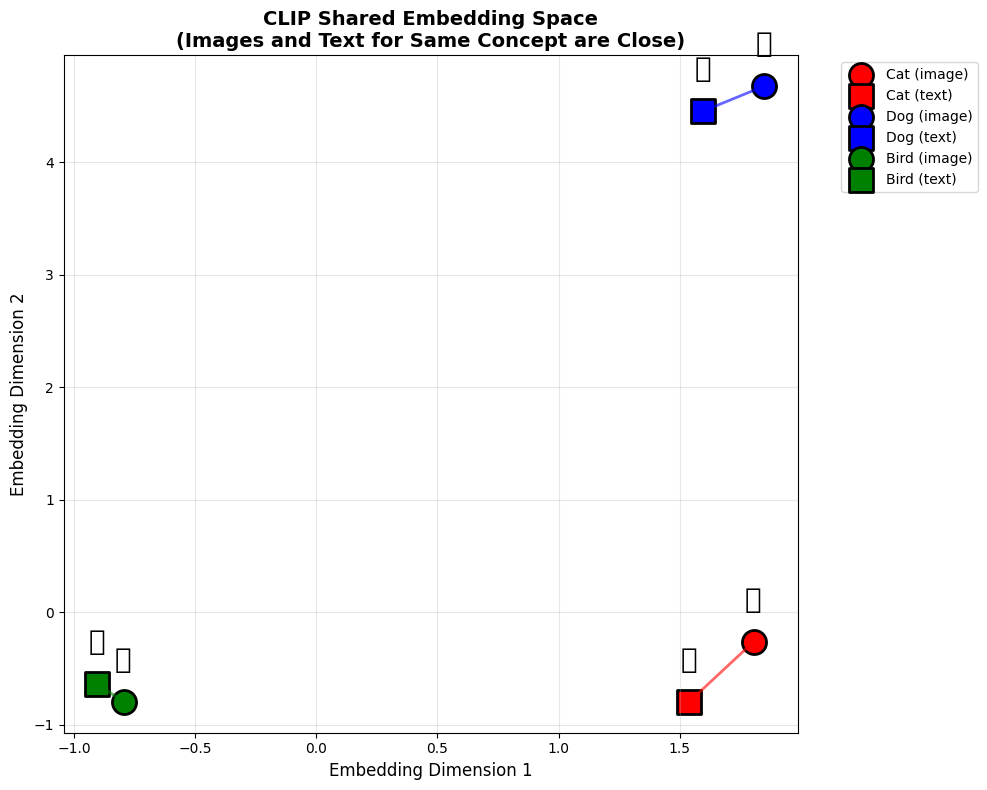

Key insight:
• Image of cat + text 'cat' = CLOSE (positive pair)
• Image of cat + text 'dog' = FAR (negative pair)
• This is what CLIP learns through contrastive training!


In [4]:
# Simulate embeddings in 2D for visualization
np.random.seed(42)

# Create 3 concepts (cat, dog, bird)
concepts = ['cat', 'dog', 'bird']
n_concepts = len(concepts)

# Each concept has an image embedding and text embedding (should be close)
concept_centers = np.random.randn(n_concepts, 2) * 3

# Add small noise to create image and text embeddings
image_embeddings = concept_centers + np.random.randn(n_concepts, 2) * 0.2
text_embeddings = concept_centers + np.random.randn(n_concepts, 2) * 0.2

# Visualize
plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green']

for i, (concept, color) in enumerate(zip(concepts, colors)):
    # Image embedding
    plt.scatter(image_embeddings[i, 0], image_embeddings[i, 1], 
                c=color, marker='o', s=300, edgecolors='black', linewidth=2,
                label=f'{concept.capitalize()} (image)')
    
    # Text embedding
    plt.scatter(text_embeddings[i, 0], text_embeddings[i, 1], 
                c=color, marker='s', s=300, edgecolors='black', linewidth=2,
                label=f'{concept.capitalize()} (text)')
    
    # Connect matching pairs
    plt.plot([image_embeddings[i, 0], text_embeddings[i, 0]],
             [image_embeddings[i, 1], text_embeddings[i, 1]],
             color=color, linewidth=2, alpha=0.6)
    
    # Add labels
    plt.text(image_embeddings[i, 0], image_embeddings[i, 1] + 0.3, 
             f'🖼️', fontsize=20, ha='center')
    plt.text(text_embeddings[i, 0], text_embeddings[i, 1] + 0.3, 
             f'📝', fontsize=20, ha='center')

plt.xlabel('Embedding Dimension 1', fontsize=12)
plt.ylabel('Embedding Dimension 2', fontsize=12)
plt.title('CLIP Shared Embedding Space\n(Images and Text for Same Concept are Close)', 
          fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Key insight:")
print("• Image of cat + text 'cat' = CLOSE (positive pair)")
print("• Image of cat + text 'dog' = FAR (negative pair)")
print("• This is what CLIP learns through contrastive training!")

## Part 4: Contrastive Learning for Multimodal Data

### The Training Objective

Given a batch of $N$ image-text pairs, CLIP creates an $N \times N$ similarity matrix:

$$
S_{ij} = \frac{f(\text{image}_i)^T g(\text{text}_j)}{\|f(\text{image}_i)\| \cdot \|g(\text{text}_j)\|}
$$

Where:
- $f(\cdot)$ is the image encoder + projection
- $g(\cdot)$ is the text encoder + projection
- The numerator is the dot product (measures alignment)
- The denominator normalizes (gives cosine similarity)

### The Loss Function

For each image-text pair $(i, i)$ on the diagonal:

**Goal**: Maximize $S_{ii}$ (matching pair), minimize $S_{ij}$ for $i \neq j$ (non-matching).

This is the **InfoNCE loss** from contrastive learning:

$$
\mathcal{L}_\text{image} = -\frac{1}{N} \sum_{i=1}^{N} \log \frac{\exp(S_{ii} / \tau)}{\sum_{j=1}^{N} \exp(S_{ij} / \tau)}
$$

$$
\mathcal{L}_\text{text} = -\frac{1}{N} \sum_{i=1}^{N} \log \frac{\exp(S_{ii} / \tau)}{\sum_{j=1}^{N} \exp(S_{ji} / \tau)}
$$

$$
\mathcal{L}_\text{CLIP} = \frac{\mathcal{L}_\text{image} + \mathcal{L}_\text{text}}{2}
$$

**Symmetric loss**: We train both directions (image→text and text→image).

**Temperature $\tau$**: Controls how hard the classification task is (typically 0.07).

Let's visualize the similarity matrix!

### Visualizing the N×N similarity matrix

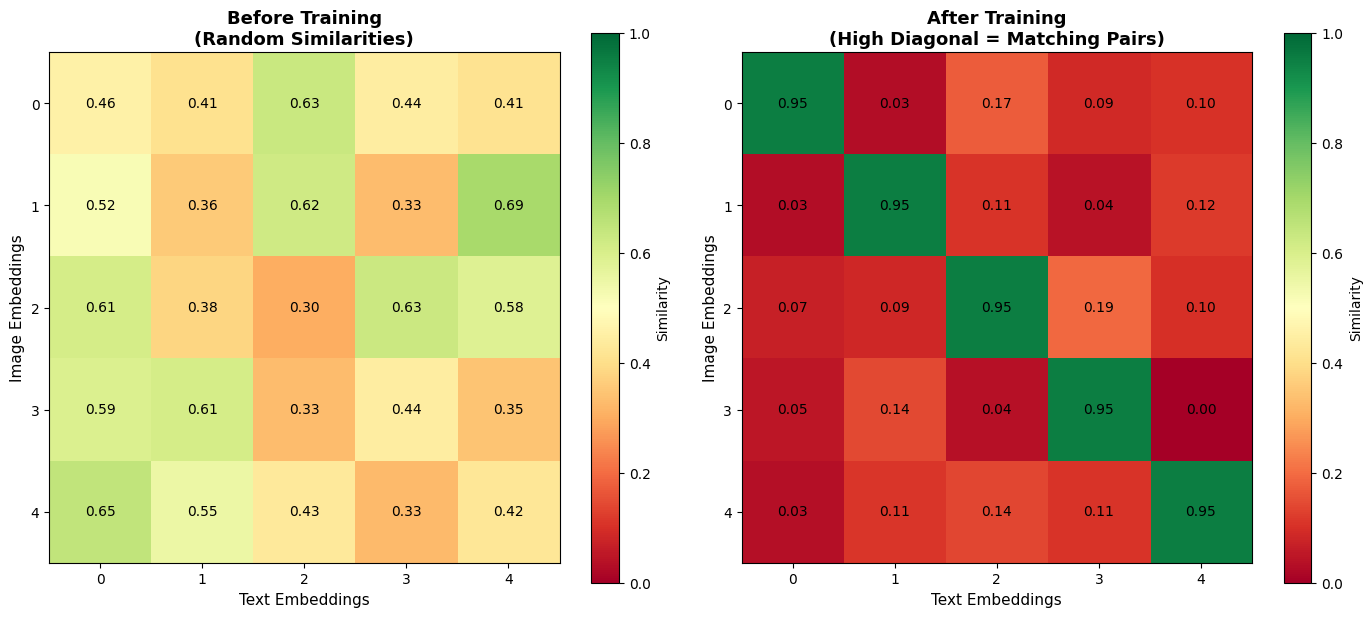

The CLIP loss maximizes diagonal (matching pairs) and minimizes off-diagonal!

For a batch of N pairs, we get N positive examples and N²-N negatives.
This is much more efficient than creating negative pairs manually!


In [5]:
# Simulate a 5x5 similarity matrix
N = 5

# Perfect case: high similarity on diagonal, low off-diagonal
similarity_perfect = np.eye(N) * 0.9 + (1 - np.eye(N)) * 0.1
similarity_perfect += np.random.randn(N, N) * 0.05  # Add small noise
np.fill_diagonal(similarity_perfect, 0.95)

# Before training: random similarities
similarity_random = np.random.rand(N, N) * 0.4 + 0.3

# Visualize both
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random (before training)
im1 = axes[0].imshow(similarity_random, cmap='RdYlGn', vmin=0, vmax=1)
axes[0].set_title('Before Training\n(Random Similarities)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Text Embeddings', fontsize=11)
axes[0].set_ylabel('Image Embeddings', fontsize=11)
for i in range(N):
    for j in range(N):
        text = axes[0].text(j, i, f'{similarity_random[i, j]:.2f}',
                           ha="center", va="center", color="black", fontsize=10)
plt.colorbar(im1, ax=axes[0], label='Similarity')

# After training (diagonal high)
im2 = axes[1].imshow(similarity_perfect, cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_title('After Training\n(High Diagonal = Matching Pairs)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Text Embeddings', fontsize=11)
axes[1].set_ylabel('Image Embeddings', fontsize=11)
for i in range(N):
    for j in range(N):
        text = axes[1].text(j, i, f'{similarity_perfect[i, j]:.2f}',
                           ha="center", va="center", color="black", fontsize=10)
plt.colorbar(im2, ax=axes[1], label='Similarity')

plt.tight_layout()
plt.show()

print("The CLIP loss maximizes diagonal (matching pairs) and minimizes off-diagonal!")
print("\nFor a batch of N pairs, we get N positive examples and N²-N negatives.")
print("This is much more efficient than creating negative pairs manually!")

## Part 5: Building the Image Encoder

### Simple CNN for MNIST

For our implementation, we'll use MNIST (28×28 grayscale digit images) and build a simple CNN encoder.

In the original CLIP:
- **ResNet-50** or **Vision Transformer (ViT)** for natural images
- We'll use a lightweight CNN since MNIST is simpler

The encoder should output a **feature vector** for each image.

In [6]:
class ImageEncoder(nn.Module):
    """
    CNN-based image encoder for MNIST.
    
    Architecture:
        Conv layers → Global pooling → Feature vector
    """
    
    def __init__(self, output_dim=128):
        super().__init__()
        
        self.conv_layers = nn.Sequential(
            # Input: 1 x 28 x 28
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32 x 14 x 14
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 64 x 7 x 7
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),  # 128 x 1 x 1
        )
        
        self.fc = nn.Linear(128, output_dim)
    
    def forward(self, x):
        """
        Args:
            x: (B, 1, 28, 28) images
        
        Returns:
            features: (B, output_dim) feature vectors
        """
        x = self.conv_layers(x)  # (B, 128, 1, 1)
        x = x.view(x.size(0), -1)  # (B, 128)
        x = self.fc(x)  # (B, output_dim)
        return x

# Test the image encoder
image_encoder = ImageEncoder(output_dim=128)
dummy_images = torch.randn(4, 1, 28, 28)
image_features = image_encoder(dummy_images)

print(f"Image encoder output shape: {image_features.shape}")
print(f"Parameters: {count_parameters(image_encoder):,}")

Image encoder output shape: torch.Size([4, 128])
Parameters: 109,632


## Part 6: Building the Text Encoder

### Transformer for Text

The text encoder processes sequences of text tokens:

1. **Tokenization**: Convert text to token IDs
2. **Embedding**: Map tokens to vectors
3. **Positional Encoding**: Add position information
4. **Transformer Layers**: Process the sequence
5. **Pooling**: Take the final token's representation (like [CLS] in BERT)

For MNIST, our "text" will be simple descriptions like:
- "a photo of the digit 0"
- "a photo of the digit 1"
- etc.

We'll use a simple character-level tokenizer for this.

### Simple character-level tokenizer

In [7]:
class SimpleTokenizer:
    """
    Character-level tokenizer for simple text.
    """
    
    def __init__(self, max_length=50):
        # Define vocabulary: lowercase letters, digits, space, and special tokens
        self.chars = '<PAD><SOS><EOS> abcdefghijklmnopqrstuvwxyz0123456789'
        self.char_to_idx = {ch: i for i, ch in enumerate(self.chars)}
        self.idx_to_char = {i: ch for i, ch in enumerate(self.chars)}
        self.max_length = max_length
        
        self.pad_token = 0
        self.sos_token = 1
        self.eos_token = 2
    
    def encode(self, text):
        """Convert text to token IDs."""
        # Lowercase and get indices
        text = text.lower()
        ids = [self.sos_token]  # Start token
        
        for ch in text:
            if ch in self.char_to_idx:
                ids.append(self.char_to_idx[ch])
            # Skip unknown characters
        
        ids.append(self.eos_token)  # End token
        
        # Pad or truncate to max_length
        if len(ids) < self.max_length:
            ids = ids + [self.pad_token] * (self.max_length - len(ids))
        else:
            ids = ids[:self.max_length]
        
        return torch.tensor(ids, dtype=torch.long)
    
    def decode(self, ids):
        """Convert token IDs back to text."""
        # Convert to list if it's a tensor
        if isinstance(ids, torch.Tensor):
            ids = ids.tolist()
        
        chars = []
        for idx in ids:
            if idx == self.eos_token:
                break
            if idx not in [self.pad_token, self.sos_token]:
                chars.append(self.idx_to_char[idx])
        return ''.join(chars)
    
    def __len__(self):
        return len(self.chars)

# Test tokenizer
tokenizer = SimpleTokenizer(max_length=30)
test_text = "a photo of the digit 5"
tokens = tokenizer.encode(test_text)
decoded = tokenizer.decode(tokens)

print(f"Original text: '{test_text}'")
print(f"Tokens: {tokens[:25]}...")  # Show first 25
print(f"Decoded: '{decoded}'")
print(f"Vocabulary size: {len(tokenizer)}")

Original text: 'a photo of the digit 5'
Tokens: tensor([ 1, 16, 15, 31, 23, 30, 35, 30, 15, 30, 21, 15, 35, 23, 20, 15, 19, 24,
        22, 24, 35, 15, 47,  2,  0])...
Decoded: 'a photo of the digit 5'
Vocabulary size: 52


### Implementing the text encoder

In [8]:
class TextEncoder(nn.Module):
    """
    Transformer-based text encoder.
    
    Architecture:
        Token embedding → Positional encoding → Transformer → Pooling → Features
    """
    
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, num_layers=3, 
                 max_length=30, output_dim=128):
        super().__init__()
        
        self.embed_dim = embed_dim
        self.max_length = max_length
        
        # Token embedding
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        
        # Positional embedding (learnable)
        self.positional_embedding = nn.Parameter(torch.randn(max_length, embed_dim))
        
        # Transformer encoder layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Output projection
        self.fc = nn.Linear(embed_dim, output_dim)
    
    def forward(self, x):
        """
        Args:
            x: (B, seq_len) token IDs
        
        Returns:
            features: (B, output_dim) text feature vectors
        """
        B, seq_len = x.shape
        
        # Token embeddings: (B, seq_len, embed_dim)
        x = self.token_embedding(x)
        
        # Add positional embeddings
        x = x + self.positional_embedding[:seq_len, :]
        
        # Create padding mask (True for padding tokens)
        # Assuming padding token ID is 0
        # Note: TransformerEncoder expects the opposite convention (True = ignore)
        # So we don't need to create a mask for this simple case
        
        # Apply transformer: (B, seq_len, embed_dim)
        x = self.transformer(x)
        
        # Pool: take the last token's representation (like EOS token)
        # In practice, could use mean pooling or first token
        x = x[:, -1, :]  # (B, embed_dim)
        
        # Project to output dimension
        x = self.fc(x)  # (B, output_dim)
        
        return x

# Test the text encoder
text_encoder = TextEncoder(
    vocab_size=len(tokenizer),
    embed_dim=128,
    num_heads=4,
    num_layers=3,
    max_length=30,
    output_dim=128
)

# Create dummy tokens
dummy_tokens = torch.randint(0, len(tokenizer), (4, 30))
text_features = text_encoder(dummy_tokens)

print(f"Text encoder output shape: {text_features.shape}")
print(f"Parameters: {count_parameters(text_encoder):,}")

Text encoder output shape: torch.Size([4, 128])
Parameters: 621,824


## Part 7: Complete CLIP Model

### Putting It All Together

Now we combine the image encoder and text encoder with projection heads to create CLIP:

1. **Image Encoder**: CNN → image features
2. **Text Encoder**: Transformer → text features
3. **Projection Heads**: Project both to a shared embedding space
4. **Normalization**: L2-normalize embeddings (for cosine similarity)
5. **Similarity**: Compute cosine similarity matrix
6. **Loss**: Symmetric contrastive loss (InfoNCE)

Let's build it!

In [9]:
class CLIP(nn.Module):
    """
    CLIP: Contrastive Language-Image Pre-training
    
    Learns a shared embedding space for images and text.
    """
    
    def __init__(self, image_encoder, text_encoder, embed_dim=128, projection_dim=64):
        super().__init__()
        
        self.image_encoder = image_encoder
        self.text_encoder = text_encoder
        
        # Projection heads to shared embedding space
        self.image_projection = nn.Linear(embed_dim, projection_dim)
        self.text_projection = nn.Linear(embed_dim, projection_dim)
        
        # Learnable temperature parameter (following original CLIP)
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
    
    def encode_image(self, images):
        """
        Encode images to embedding space.
        
        Args:
            images: (B, C, H, W)
        
        Returns:
            embeddings: (B, projection_dim) normalized embeddings
        """
        features = self.image_encoder(images)  # (B, embed_dim)
        embeddings = self.image_projection(features)  # (B, projection_dim)
        # L2 normalize
        embeddings = F.normalize(embeddings, p=2, dim=-1)
        return embeddings
    
    def encode_text(self, texts):
        """
        Encode text to embedding space.
        
        Args:
            texts: (B, seq_len) token IDs
        
        Returns:
            embeddings: (B, projection_dim) normalized embeddings
        """
        features = self.text_encoder(texts)  # (B, embed_dim)
        embeddings = self.text_projection(features)  # (B, projection_dim)
        # L2 normalize
        embeddings = F.normalize(embeddings, p=2, dim=-1)
        return embeddings
    
    def forward(self, images, texts):
        """
        Forward pass: compute similarity matrix.
        
        Args:
            images: (B, C, H, W)
            texts: (B, seq_len)
        
        Returns:
            logits: (B, B) similarity matrix scaled by temperature
        """
        # Get embeddings
        image_embeddings = self.encode_image(images)  # (B, projection_dim)
        text_embeddings = self.encode_text(texts)  # (B, projection_dim)
        
        # Compute similarity matrix: (B, B)
        # Each element (i, j) = cosine similarity between image_i and text_j
        logit_scale = self.logit_scale.exp()
        logits = logit_scale * image_embeddings @ text_embeddings.t()
        
        return logits

# Create CLIP model
clip_model = CLIP(
    image_encoder=ImageEncoder(output_dim=128),
    text_encoder=TextEncoder(
        vocab_size=len(tokenizer),
        embed_dim=128,
        num_heads=4,
        num_layers=3,
        max_length=30,
        output_dim=128
    ),
    embed_dim=128,
    projection_dim=64
).to(device)

print("CLIP Model Architecture:")
print(f"  Image encoder: {count_parameters(clip_model.image_encoder):,} parameters")
print(f"  Text encoder: {count_parameters(clip_model.text_encoder):,} parameters")
print(f"  Total: {count_parameters(clip_model):,} parameters")
print(f"\n  Embedding dimension: 128")
print(f"  Projection dimension: 64")
print(f"  Initial temperature: {(1/clip_model.logit_scale.exp().item()):.3f}")

CLIP Model Architecture:
  Image encoder: 109,632 parameters
  Text encoder: 621,824 parameters
  Total: 747,969 parameters

  Embedding dimension: 128
  Projection dimension: 64


  Initial temperature: 0.070


### Test the forward pass

In [10]:
# Test forward pass
batch_size = 4
test_images = torch.randn(batch_size, 1, 28, 28).to(device)
test_texts = torch.randint(0, len(tokenizer), (batch_size, 30)).to(device)

with torch.no_grad():
    logits = clip_model(test_images, test_texts)

print(f"Input images shape: {test_images.shape}")
print(f"Input texts shape: {test_texts.shape}")
print(f"Similarity matrix shape: {logits.shape}")
print(f"\nSimilarity matrix (before training):")
print(logits.cpu().numpy())
print(f"\nDiagonal should be high after training (matching pairs)!")

Input images shape: torch.Size([4, 1, 28, 28])
Input texts shape: torch.Size([4, 30])
Similarity matrix shape: torch.Size([4, 4])

Similarity matrix (before training):
[[-0.58884895 -2.4305124  -1.0078533  -1.2521163 ]
 [-0.56649446 -2.3078356  -1.0263716  -1.1550642 ]
 [-0.2257374  -2.162601   -0.9562656  -0.9999829 ]
 [-0.6844822  -2.4258432  -1.2747023  -1.1113572 ]]

Diagonal should be high after training (matching pairs)!


## Part 8: The CLIP Loss Function

### Implementing Symmetric Contrastive Loss

The CLIP loss is symmetric: we compute cross-entropy in both directions.

**Image-to-Text**: For each image, the correct text is on the diagonal.

**Text-to-Image**: For each text, the correct image is on the diagonal.

We average both losses.

In [11]:
def clip_loss(logits):
    """
    Compute symmetric contrastive loss for CLIP.
    
    Args:
        logits: (B, B) similarity matrix
    
    Returns:
        loss: scalar loss value
    """
    B = logits.shape[0]
    
    # Labels: diagonal elements are the correct matches
    labels = torch.arange(B, device=logits.device)
    
    # Image-to-text loss (each row is a distribution over texts)
    loss_i2t = F.cross_entropy(logits, labels)
    
    # Text-to-image loss (each column is a distribution over images)
    loss_t2i = F.cross_entropy(logits.t(), labels)
    
    # Symmetric loss
    loss = (loss_i2t + loss_t2i) / 2
    
    return loss

# Test the loss
test_loss = clip_loss(logits)
print(f"CLIP loss (untrained): {test_loss.item():.4f}")
print(f"\nFor {batch_size} pairs, random chance would give loss ≈ {np.log(batch_size):.4f}")
print("(This is the entropy of a uniform distribution over 4 classes)")

CLIP loss (untrained): 1.4634

For 4 pairs, random chance would give loss ≈ 1.3863
(This is the entropy of a uniform distribution over 4 classes)


## Part 9: Preparing the MNIST Dataset with Text Captions

### Creating Image-Text Pairs

For each MNIST image, we need to create a text description. We'll use a simple template:

**Template**: "a photo of the digit {label}"

This gives us natural language supervision for training CLIP!

In [12]:
class MNISTWithCaptions(Dataset):
    """
    MNIST dataset with text captions.
    
    Each image gets a caption: "a photo of the digit X"
    """
    
    def __init__(self, mnist_dataset, tokenizer):
        self.mnist_dataset = mnist_dataset
        self.tokenizer = tokenizer
    
    def __len__(self):
        return len(self.mnist_dataset)
    
    def __getitem__(self, idx):
        image, label = self.mnist_dataset[idx]
        
        # Create caption
        caption = f"a photo of the digit {label}"
        
        # Tokenize
        tokens = self.tokenizer.encode(caption)
        
        return image, tokens, label

# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),
])

mnist_train = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

mnist_test = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Wrap with captions
train_dataset = MNISTWithCaptions(mnist_train, tokenizer)
test_dataset = MNISTWithCaptions(mnist_test, tokenizer)

print(f"Training samples: {len(train_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")

Training samples: 60,000
Test samples: 10,000


### Visualize samples with captions

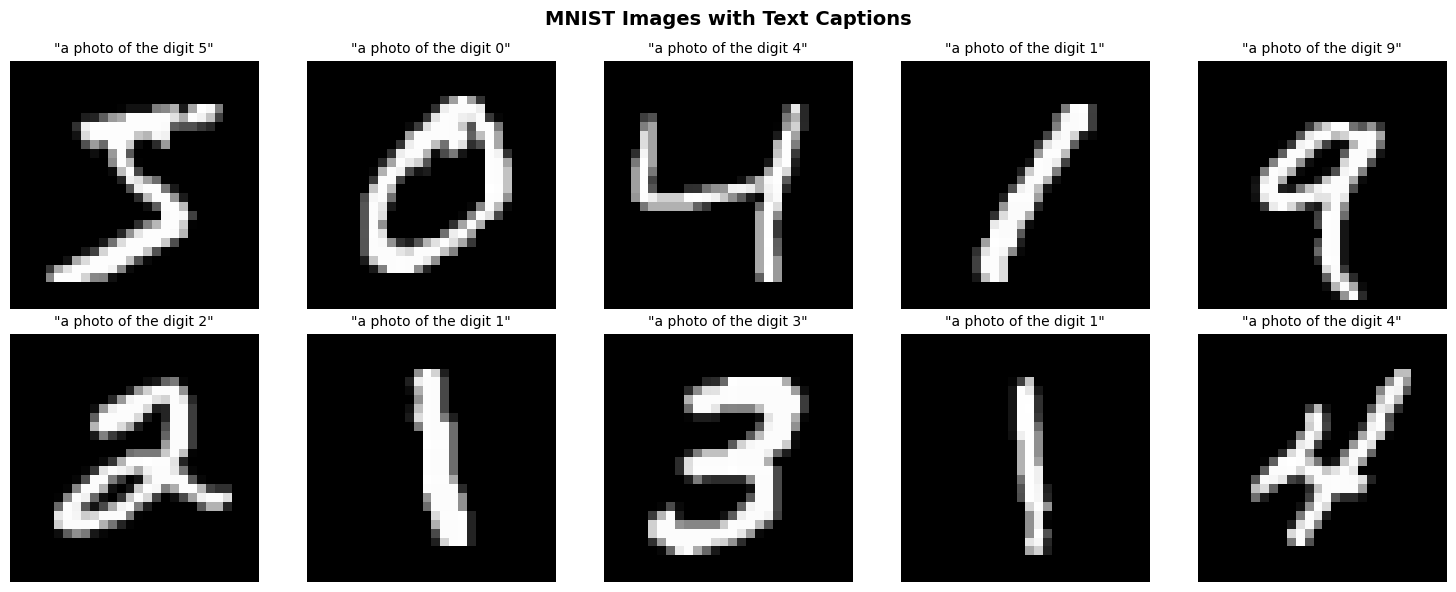

Each image is paired with a natural language description!
This is the foundation of CLIP training.


In [13]:
# Show some samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    image, tokens, label = train_dataset[i]
    caption = tokenizer.decode(tokens)
    
    # Denormalize for visualization
    img = image.squeeze().numpy() * MNIST_STD + MNIST_MEAN
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'"{caption}"', fontsize=10)
    axes[i].axis('off')

plt.suptitle('MNIST Images with Text Captions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each image is paired with a natural language description!")
print("This is the foundation of CLIP training.")

### Create data loaders

In [14]:
batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,  # Avoid multiprocessing issues in notebook execution
    pin_memory=True,
    drop_last=True  # Ensure all batches have same size
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,  # Avoid multiprocessing issues in notebook execution
    pin_memory=True
)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Batch size: {batch_size}")

Training batches: 234
Test batches: 40
Batch size: 256


## Part 10: Training CLIP

### Training Configuration

We'll train CLIP with:
- **Optimizer**: AdamW with weight decay
- **Learning rate**: 3e-4 with cosine annealing
- **Loss**: Symmetric contrastive loss
- **Epochs**: 3 for testing (use 10+ for production)

The model learns to align images with their text descriptions!

In [15]:
# Training configuration
num_epochs = 3  # Reduced for faster testing (10 in production)
learning_rate = 3e-4
weight_decay = 0.01

# Optimizer
optimizer = torch.optim.AdamW(clip_model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs * len(train_loader))

print("Training Configuration:")
print(f"  Epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Weight decay: {weight_decay}")
print(f"  Optimizer: AdamW")
print(f"  Scheduler: Cosine annealing")

Training Configuration:
  Epochs: 3
  Learning rate: 0.0003
  Weight decay: 0.01
  Optimizer: AdamW
  Scheduler: Cosine annealing


### Training loop

In [16]:
def train_epoch(model, loader, optimizer, scheduler, device):
    """
    Train CLIP for one epoch.
    """
    model.train()
    total_loss = 0
    
    pbar = tqdm(loader, desc='Training')
    for images, texts, labels in pbar:
        images = images.to(device)
        texts = texts.to(device)
        
        # Forward pass
        logits = model(images, texts)
        loss = clip_loss(logits)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        # Track loss
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    return avg_loss

@torch.no_grad()
def evaluate(model, loader, device):
    """
    Evaluate CLIP on test set.
    """
    model.eval()
    total_loss = 0
    
    for images, texts, labels in loader:
        images = images.to(device)
        texts = texts.to(device)
        
        logits = model(images, texts)
        loss = clip_loss(logits)
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    return avg_loss

print("Training functions defined!")

Training functions defined!


### Run training

In [17]:
history = TrainingHistory()

print("Starting CLIP training...\n")

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")
    
    # Train
    train_loss = train_epoch(clip_model, train_loader, optimizer, scheduler, device)
    
    # Evaluate
    test_loss = evaluate(clip_model, test_loader, device)
    
    # Log
    history.update(train_loss=train_loss, val_loss=test_loss)
    
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"Temperature: {1/clip_model.logit_scale.exp().item():.4f}\n")

print("Training complete!")

Starting CLIP training...

Epoch 1/3


Training:   0%|          | 0/234 [00:00<?, ?it/s]

/Users/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Training:   0%|          | 0/234 [00:00<?, ?it/s, loss=5.6616]

Training:   0%|          | 1/234 [00:00<02:07,  1.83it/s, loss=5.6616]

...

Training:  99%|█████████▊| 231/234 [00:19<00:00, 13.49it/s, loss=3.3210]

Training: 100%|█████████▉| 233/234 [00:19<00:00, 13.47it/s, loss=3.3210]

Training: 100%|█████████▉| 233/234 [00:19<00:00, 13.47it/s, loss=3.4138]

Training: 100%|██████████| 234/234 [00:19<00:00, 11.76it/s, loss=3.4138]

Train Loss: 3.3599 | Test Loss: 3.2785
Temperature: 0.0705

Training complete!


### Plot training curves

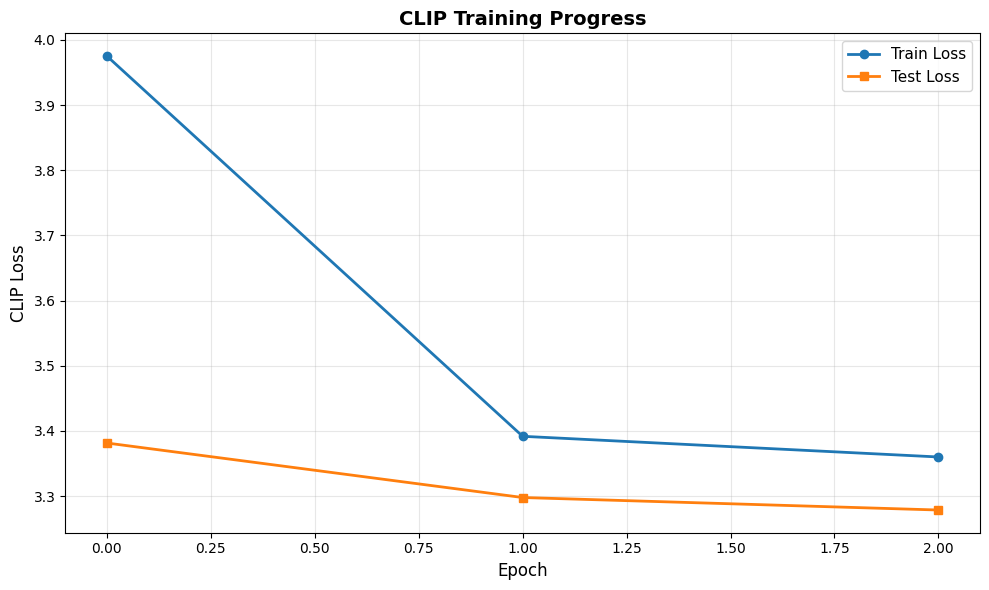

Final train loss: 3.3599
Final test loss: 3.2785
Improvement: 15.5%


In [18]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['train_loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(history.history['val_loss'], label='Test Loss', marker='s', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('CLIP Loss', fontsize=12)
plt.title('CLIP Training Progress', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

train_losses = history.history['train_loss']
val_losses = history.history['val_loss']

print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final test loss: {val_losses[-1]:.4f}")
print(f"Improvement: {(train_losses[0] - train_losses[-1]) / train_losses[0] * 100:.1f}%")

## Part 11: Zero-Shot Classification

### The Magic of CLIP

Now comes the exciting part: **zero-shot classification**!

**How it works**:
1. Write text descriptions for all classes ("a photo of the digit 0", etc.)
2. Encode all text descriptions → text embeddings
3. Encode the image → image embedding
4. Compute similarity between image and all text embeddings
5. Predicted class = text with highest similarity

**No retraining needed!** We can classify any image using natural language.

In [19]:
def zero_shot_classify(model, image, text_descriptions, tokenizer, device):
    """
    Classify an image using text descriptions (zero-shot).
    
    Args:
        model: CLIP model
        image: (1, C, H, W) image tensor
        text_descriptions: List of text descriptions for each class
        tokenizer: Text tokenizer
        device: Device to run on
    
    Returns:
        probs: Probability distribution over classes
        pred: Predicted class index
    """
    model.eval()
    
    with torch.no_grad():
        # Encode image
        image = image.to(device)
        image_embedding = model.encode_image(image)  # (1, projection_dim)
        
        # Encode all text descriptions
        text_tokens = torch.stack([tokenizer.encode(text) for text in text_descriptions])
        text_tokens = text_tokens.to(device)  # (num_classes, seq_len)
        text_embeddings = model.encode_text(text_tokens)  # (num_classes, projection_dim)
        
        # Compute similarities (cosine similarity, already normalized)
        similarities = image_embedding @ text_embeddings.t()  # (1, num_classes)
        
        # Apply temperature and softmax
        logit_scale = model.logit_scale.exp()
        logits = logit_scale * similarities
        probs = F.softmax(logits, dim=-1).squeeze(0)  # (num_classes,)
        
        pred = torch.argmax(probs).item()
    
    return probs.cpu(), pred

# Define text descriptions for MNIST digits
text_descriptions = [f"a photo of the digit {i}" for i in range(10)]

print("Zero-shot classifier ready!")
print("\nText descriptions:")
for i, desc in enumerate(text_descriptions):
    print(f"  {i}: '{desc}'")

Zero-shot classifier ready!

Text descriptions:
  0: 'a photo of the digit 0'
  1: 'a photo of the digit 1'
  2: 'a photo of the digit 2'
  3: 'a photo of the digit 3'
  4: 'a photo of the digit 4'
  5: 'a photo of the digit 5'
  6: 'a photo of the digit 6'
  7: 'a photo of the digit 7'
  8: 'a photo of the digit 8'
  9: 'a photo of the digit 9'


### Test zero-shot classification on sample images

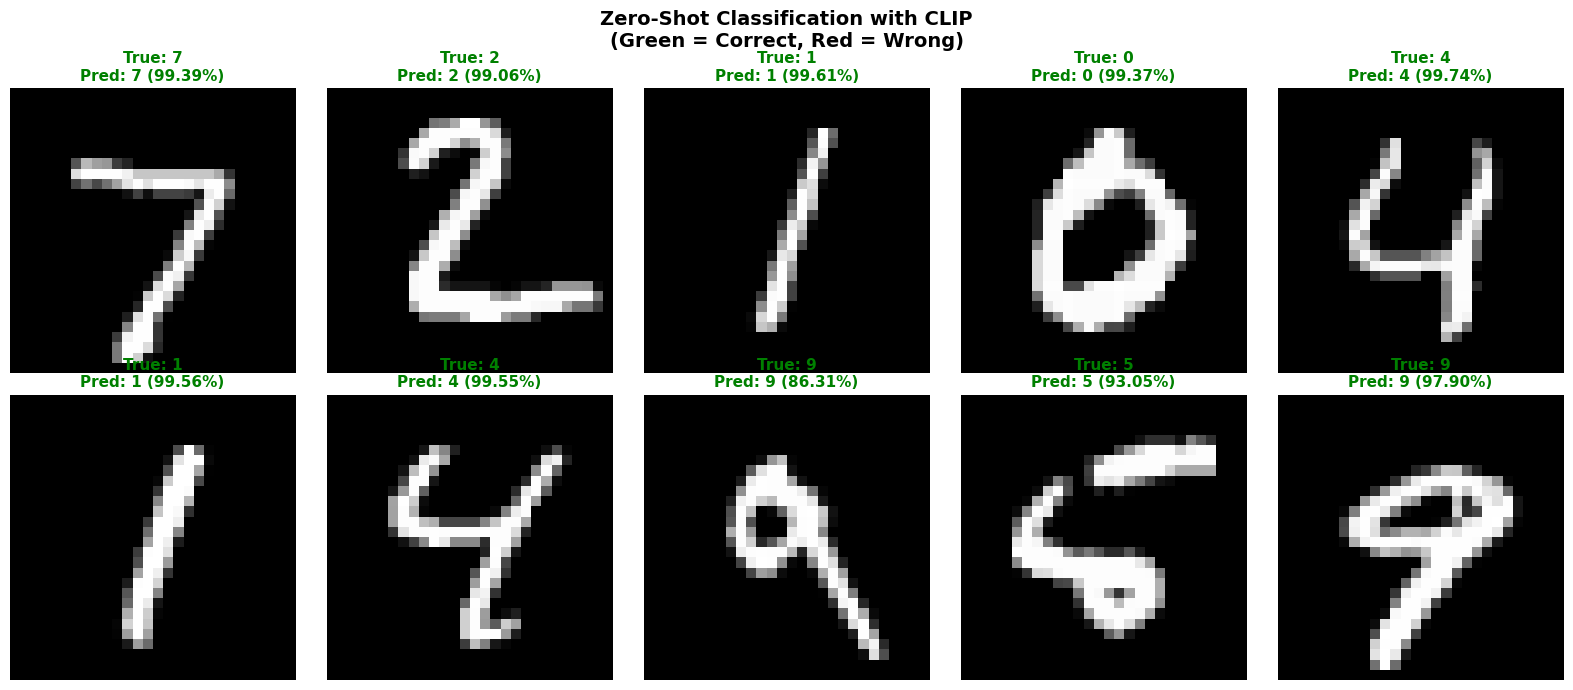

In [20]:
# Test on a few samples
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for i in range(10):
    # Get test image
    image, _, true_label = test_dataset[i]
    image_batch = image.unsqueeze(0)  # Add batch dimension
    
    # Zero-shot classify
    probs, pred = zero_shot_classify(clip_model, image_batch, text_descriptions, tokenizer, device)
    
    # Visualize
    ax = axes[i]
    
    # Denormalize for display
    img = image.squeeze().numpy() * MNIST_STD + MNIST_MEAN
    ax.imshow(img, cmap='gray')
    
    # Color code: green if correct, red if wrong
    color = 'green' if pred == true_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred} ({probs[pred]:.2%})', 
                 fontsize=11, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Zero-Shot Classification with CLIP\n(Green = Correct, Red = Wrong)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Compute zero-shot accuracy on entire test set

In [21]:
@torch.no_grad()
def compute_zero_shot_accuracy(model, loader, text_descriptions, tokenizer, device):
    """
    Compute zero-shot classification accuracy.
    """
    model.eval()
    
    # Encode text descriptions once
    text_tokens = torch.stack([tokenizer.encode(text) for text in text_descriptions])
    text_tokens = text_tokens.to(device)
    text_embeddings = model.encode_text(text_tokens)  # (num_classes, projection_dim)
    
    correct = 0
    total = 0
    
    for images, _, labels in tqdm(loader, desc='Zero-shot evaluation'):
        images = images.to(device)
        labels = labels.to(device)
        
        # Encode images
        image_embeddings = model.encode_image(images)  # (B, projection_dim)
        
        # Compute similarities
        similarities = image_embeddings @ text_embeddings.t()  # (B, num_classes)
        
        # Predict
        preds = similarities.argmax(dim=-1)
        
        # Count correct
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    accuracy = 100. * correct / total
    return accuracy

# Compute accuracy
accuracy = compute_zero_shot_accuracy(clip_model, test_loader, text_descriptions, tokenizer, device)

print(f"\nZero-Shot Accuracy: {accuracy:.2f}%")
print(f"\nThis is achieved WITHOUT any task-specific training!")
print("We only trained on image-text matching, not digit classification.")

Zero-shot evaluation:   0%|          | 0/40 [00:00<?, ?it/s]

Zero-shot evaluation:   2%|▎         | 1/40 [00:00<00:04,  8.35it/s]

Zero-shot evaluation:  15%|█▌        | 6/40 [00:00<00:01, 27.55it/s]

Zero-shot evaluation:  28%|██▊       | 11/40 [00:00<00:00, 33.58it/s]

Zero-shot evaluation:  40%|████      | 16/40 [00:00<00:00, 37.63it/s]

...

Zero-shot evaluation:  65%|██████▌   | 26/40 [00:00<00:00, 41.35it/s]

Zero-shot evaluation:  78%|███████▊  | 31/40 [00:00<00:00, 42.38it/s]

Zero-shot evaluation:  90%|█████████ | 36/40 [00:00<00:00, 41.98it/s]

Zero-shot evaluation: 100%|██████████| 40/40 [00:01<00:00, 38.97it/s]


Zero-Shot Accuracy: 98.26%

This is achieved WITHOUT any task-specific training!
We only trained on image-text matching, not digit classification.


## Part 12: Visualizing the Embedding Space

### Exploring the Multimodal Space

Let's visualize how CLIP aligns images and text in the shared embedding space.

We'll use t-SNE to reduce the high-dimensional embeddings to 2D and see if:
1. Images and their corresponding text are close together
2. Different digits form separate clusters
3. The space is semantically meaningful

In [22]:
@torch.no_grad()
def extract_embeddings(model, loader, tokenizer, device, max_samples=1000):
    """
    Extract image and text embeddings from the model.
    """
    model.eval()
    
    image_embeddings_list = []
    text_embeddings_list = []
    labels_list = []
    
    samples_collected = 0
    
    for images, texts, labels in loader:
        if samples_collected >= max_samples:
            break
        
        images = images.to(device)
        texts = texts.to(device)
        
        # Get embeddings
        image_emb = model.encode_image(images)
        text_emb = model.encode_text(texts)
        
        image_embeddings_list.append(image_emb.cpu())
        text_embeddings_list.append(text_emb.cpu())
        labels_list.append(labels)
        
        samples_collected += images.size(0)
    
    image_embeddings = torch.cat(image_embeddings_list, dim=0)
    text_embeddings = torch.cat(text_embeddings_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    
    return image_embeddings, text_embeddings, labels

# Extract embeddings
print("Extracting embeddings...")
image_emb, text_emb, labels = extract_embeddings(clip_model, test_loader, tokenizer, device, max_samples=1000)

print(f"Image embeddings shape: {image_emb.shape}")
print(f"Text embeddings shape: {text_emb.shape}")
print(f"Labels shape: {labels.shape}")

Extracting embeddings...
Image embeddings shape: torch.Size([1024, 64])
Text embeddings shape: torch.Size([1024, 64])
Labels shape: torch.Size([1024])


### Apply t-SNE to visualize embeddings

In [23]:
from sklearn.manifold import TSNE

# Combine image and text embeddings for joint visualization
all_embeddings = torch.cat([image_emb, text_emb], dim=0).numpy()
all_labels = torch.cat([labels, labels], dim=0).numpy()
modality = ['image'] * len(image_emb) + ['text'] * len(text_emb)

print("Computing t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(all_embeddings)

# Split back into image and text
image_2d = embeddings_2d[:len(image_emb)]
text_2d = embeddings_2d[len(image_emb):]

print("t-SNE complete!")

Computing t-SNE (this may take a minute)...


t-SNE complete!


### Visualize the multimodal embedding space

/var/folders/wz/x29jb7_x5rdc_5dcjr4qnhg00000gn/T/ipykernel_41254/923728133.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(text_2d[:, 0], text_2d[:, 1],


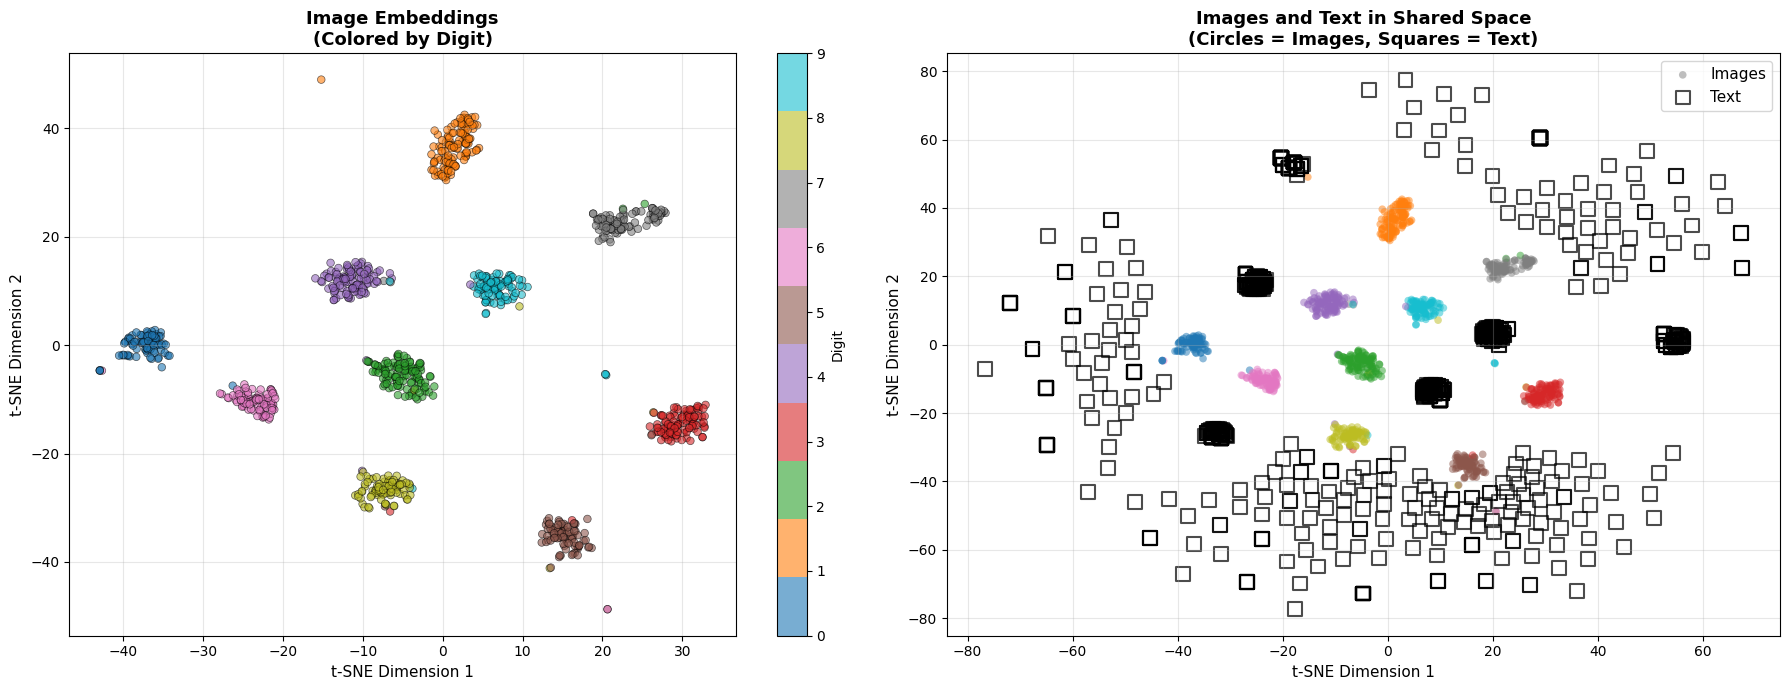

Key observations:
• Images of the same digit cluster together (left plot)
• Text embeddings (squares) appear near their corresponding image clusters (right plot)
• The model learned to align visual and textual representations!


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Images only (colored by digit)
ax = axes[0]
scatter = ax.scatter(image_2d[:, 0], image_2d[:, 1], 
                     c=labels[:len(image_emb)].numpy(), cmap='tab10', 
                     alpha=0.6, s=30, edgecolors='black', linewidths=0.5)
ax.set_title('Image Embeddings\n(Colored by Digit)', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
plt.colorbar(scatter, ax=ax, ticks=range(10), label='Digit')
ax.grid(True, alpha=0.3)

# Plot 2: Images and text together
ax = axes[1]
# Plot images as circles
ax.scatter(image_2d[:, 0], image_2d[:, 1], 
           c=labels[:len(image_emb)].numpy(), cmap='tab10', 
           alpha=0.5, s=30, marker='o', label='Images', edgecolors='none')
# Plot text as squares
ax.scatter(text_2d[:, 0], text_2d[:, 1], 
           c=labels[len(image_emb):].numpy(), cmap='tab10', 
           alpha=0.7, s=100, marker='s', label='Text', edgecolors='black', linewidths=1.5)
ax.set_title('Images and Text in Shared Space\n(Circles = Images, Squares = Text)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key observations:")
print("• Images of the same digit cluster together (left plot)")
print("• Text embeddings (squares) appear near their corresponding image clusters (right plot)")
print("• The model learned to align visual and textual representations!")

## Part 13: Image Search with Natural Language

### Text-to-Image Search

One powerful application of CLIP: **search images using text descriptions**!

**How it works**:
1. Encode a text query → text embedding
2. Encode all images → image embeddings
3. Compute similarity between query and all images
4. Return top-k most similar images

Let's build an image search engine!

In [25]:
@torch.no_grad()
def search_images_by_text(model, query_text, image_dataset, tokenizer, device, top_k=5):
    """
    Search for images matching a text query.
    
    Args:
        model: CLIP model
        query_text: Text description to search for
        image_dataset: Dataset of images
        tokenizer: Text tokenizer
        device: Device
        top_k: Number of top results to return
    
    Returns:
        top_indices: Indices of top-k matching images
        top_similarities: Similarity scores
    """
    model.eval()
    
    # Encode query text
    query_tokens = tokenizer.encode(query_text).unsqueeze(0).to(device)
    query_embedding = model.encode_text(query_tokens)  # (1, projection_dim)
    
    # Encode all images (use a subset for speed)
    max_images = min(1000, len(image_dataset))
    image_embeddings = []
    
    for i in range(max_images):
        image, _, _ = image_dataset[i]
        image = image.unsqueeze(0).to(device)
        emb = model.encode_image(image)
        image_embeddings.append(emb)
    
    image_embeddings = torch.cat(image_embeddings, dim=0)  # (max_images, projection_dim)
    
    # Compute similarities
    similarities = query_embedding @ image_embeddings.t()  # (1, max_images)
    similarities = similarities.squeeze(0)  # (max_images,)
    
    # Get top-k
    top_k_sims, top_k_indices = torch.topk(similarities, k=top_k)
    
    return top_k_indices.cpu(), top_k_sims.cpu()

print("Image search function ready!")

Image search function ready!


### Search for images using text queries


Searching for: 'a photo of the digit 3'


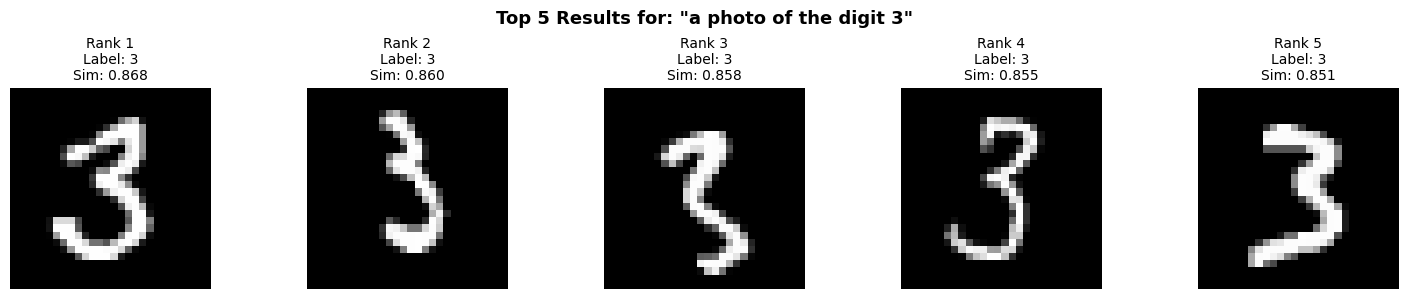


Searching for: 'a photo of the digit 7'


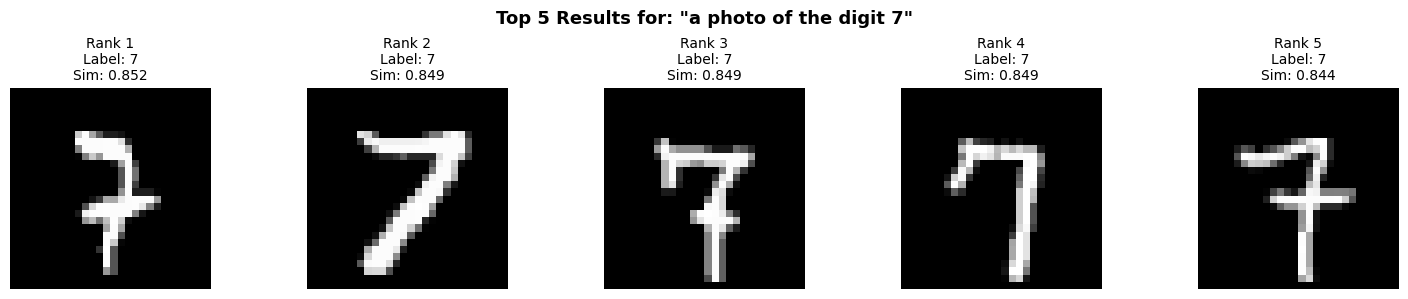


Searching for: 'a photo of the digit 0'


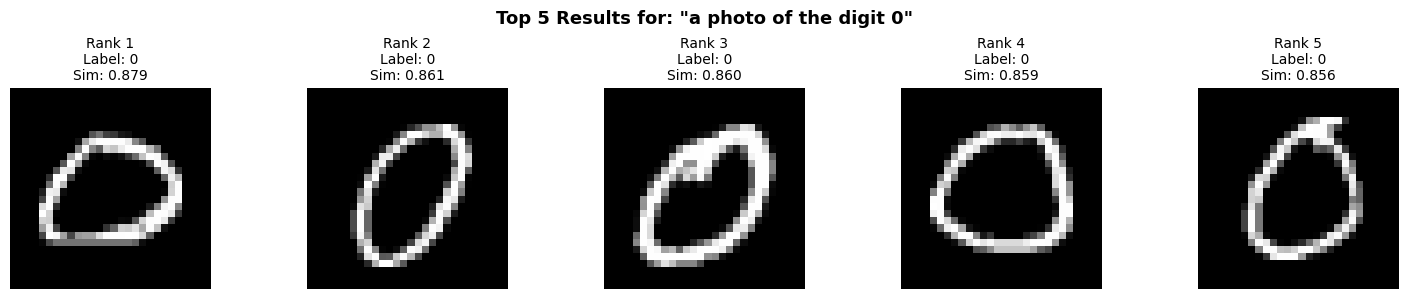

In [26]:
# Test queries
queries = [
    "a photo of the digit 3",
    "a photo of the digit 7",
    "a photo of the digit 0",
]

for query in queries:
    print(f"\nSearching for: '{query}'")
    
    # Search
    top_indices, top_sims = search_images_by_text(
        clip_model, query, test_dataset, tokenizer, device, top_k=5
    )
    
    # Visualize results
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    
    for i, (idx, sim) in enumerate(zip(top_indices, top_sims)):
        image, _, label = test_dataset[int(idx)]
        
        # Denormalize
        img = image.squeeze().numpy() * MNIST_STD + MNIST_MEAN
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Rank {i+1}\nLabel: {label}\nSim: {sim:.3f}', fontsize=10)
        axes[i].axis('off')
    
    plt.suptitle(f'Top 5 Results for: "{query}"', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Part 14: Understanding Compositionality

### Testing Compositional Understanding

One remarkable property of CLIP: **compositional understanding**.

The model can understand combinations of concepts it saw during training.

For example:
- "a photo of the digit 5" (seen during training)
- "the digit five" (different phrasing, same concept)
- "number 5" (alternative description)

Let's test if our CLIP model generalizes to different phrasings!

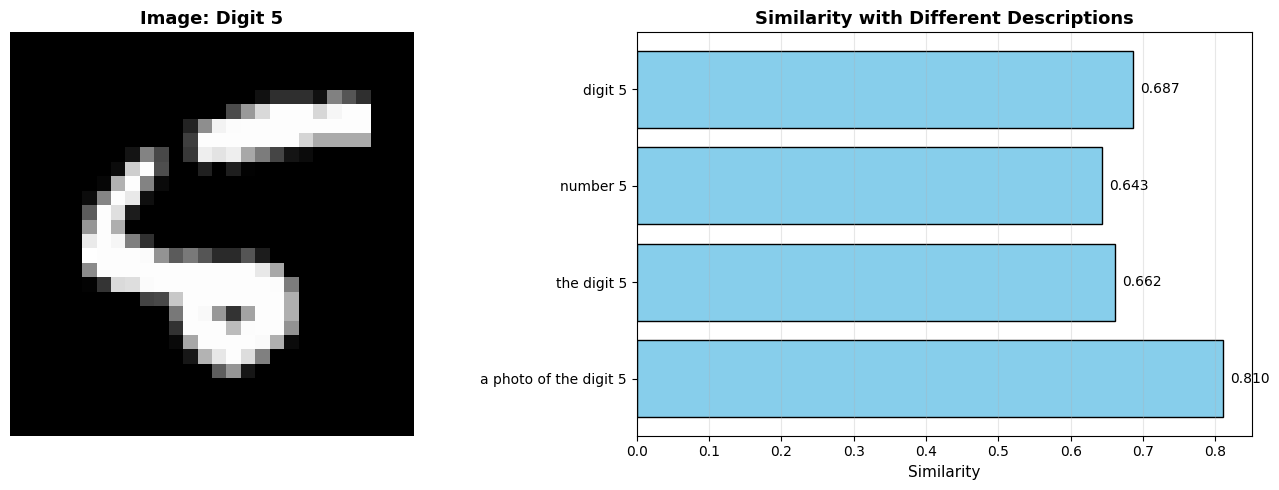

Notice: The model recognizes the image across different phrasings!
This shows compositional understanding of language.


In [27]:
# Test different phrasings for the same digit
digit = 5

# Different text descriptions for digit 5
descriptions = [
    f"a photo of the digit {digit}",  # Training format
    f"the digit {digit}",
    f"number {digit}",
    f"digit {digit}",
]

# Get a sample image of digit 5
sample_idx = None
for i in range(len(test_dataset)):
    _, _, label = test_dataset[i]
    if label == digit:
        sample_idx = i
        break

image, _, true_label = test_dataset[sample_idx]
image_batch = image.unsqueeze(0)

# Compute similarity for each description
clip_model.eval()
with torch.no_grad():
    image_emb = clip_model.encode_image(image_batch.to(device))
    
    similarities = []
    for desc in descriptions:
        tokens = tokenizer.encode(desc).unsqueeze(0).to(device)
        text_emb = clip_model.encode_text(tokens)
        sim = (image_emb @ text_emb.t()).item()
        similarities.append(sim)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Show image
ax = axes[0]
img = image.squeeze().numpy() * MNIST_STD + MNIST_MEAN
ax.imshow(img, cmap='gray')
ax.set_title(f'Image: Digit {true_label}', fontsize=13, fontweight='bold')
ax.axis('off')

# Show similarities
ax = axes[1]
bars = ax.barh(range(len(descriptions)), similarities, color='skyblue', edgecolor='black')
ax.set_yticks(range(len(descriptions)))
ax.set_yticklabels(descriptions, fontsize=10)
ax.set_xlabel('Similarity', fontsize=11)
ax.set_title('Similarity with Different Descriptions', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, sim) in enumerate(zip(bars, similarities)):
    ax.text(sim + 0.01, i, f'{sim:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Notice: The model recognizes the image across different phrasings!")
print("This shows compositional understanding of language.")

## Part 15: Key Takeaways

### What We Learned

Congratulations! You've built CLIP from scratch and explored its capabilities. Let's recap:

#### 1. The CLIP Revolution
- **Before CLIP**: Supervised learning on labeled datasets (expensive, limited)
- **With CLIP**: Learn from image-text pairs (abundant on the web)
- **Result**: Zero-shot classification, multimodal understanding

#### 2. Dual Encoder Architecture
- **Image Encoder**: CNN or Vision Transformer → visual features
- **Text Encoder**: Transformer → language features
- **Projection Heads**: Map to shared embedding space
- **Key**: Both modalities in the same space enables cross-modal reasoning

#### 3. Contrastive Learning
- **N×N similarity matrix**: All pairs in a batch
- **Diagonal**: Matching pairs (maximize)
- **Off-diagonal**: Non-matching pairs (minimize)
- **Symmetric loss**: Train both image→text and text→image

#### 4. Zero-Shot Classification
- **No retraining needed**: Just write text descriptions
- **How**: Compare image embedding with all class text embeddings
- **Prediction**: Class with highest similarity
- **Powerful**: Works on unseen classes!

#### 5. Applications
- **Image search**: Find images using natural language
- **Text-to-image**: Foundation for DALL-E, Stable Diffusion
- **Multimodal AI**: GPT-4 Vision, Flamingo, LLaVA
- **Compositionality**: Understand novel combinations of concepts

### The Bigger Picture

**CLIP represents a paradigm shift**:

1. **Natural Supervision**: Learn from naturally occurring data (image-text pairs)
2. **Scalability**: 400M pairs from the web vs. 1M labeled images
3. **Generalization**: Zero-shot transfer to new tasks
4. **Flexibility**: Natural language as the interface

### Real-World CLIP

OpenAI's CLIP:
- **Data**: 400M image-text pairs from the internet
- **Models**: ResNet-50 to ViT-L/14 (various sizes)
- **Training**: Weeks on hundreds of GPUs
- **Performance**: Matches supervised ImageNet on many tasks

### Why CLIP Matters

CLIP is the foundation for:
- **DALL-E 2**: Uses CLIP embeddings to guide diffusion models
- **Stable Diffusion**: CLIP text encoder for conditioning
- **GPT-4 Vision**: Multimodal understanding
- **Flamingo, LLaVA**: Vision-language models

**The key insight**: A shared embedding space for vision and language enables entirely new capabilities!

## Part 16: Going Further

### Improvements and Extensions

Our simplified CLIP can be enhanced in many ways:

#### 1. Architecture Improvements
- **Vision Transformer**: Replace CNN with ViT (better scaling)
- **Larger models**: Increase depth, width, embedding dimensions
- **Better text encoder**: Use a pre-trained language model (BERT, GPT)

#### 2. Training Improvements
- **Larger datasets**: Natural images with captions (MS-COCO, Conceptual Captions)
- **Bigger batches**: 1024+ for more negatives per sample
- **Data augmentation**: Color jitter, random crops for images
- **Mixed precision**: FP16 training for speed

#### 3. Advanced Techniques
- **Hard negative mining**: Focus on difficult negatives
- **Temperature scheduling**: Anneal temperature during training
- **Multi-task learning**: Add auxiliary tasks (e.g., masked language modeling)

#### 4. Applications to Explore
- **Fine-tuning**: Adapt CLIP to specific domains
- **Image generation**: Use CLIP as a guide for generative models
- **Visual question answering**: Combine with language model
- **Video understanding**: Extend to video-text pairs

### Experiments to Try

Deepen your understanding:

1. **Different text templates**: Try "image of digit X", "handwritten X", etc.
2. **Batch size impact**: Compare training with 64, 128, 256 batch sizes
3. **Temperature sensitivity**: Train with different temperature values
4. **Embedding dimension**: Try 32, 64, 128, 256 dimensions
5. **Asymmetric encoders**: Use different capacities for image and text

### Further Reading

**Papers**:
- Original CLIP: "Learning Transferable Visual Models From Natural Language Supervision" (Radford et al., 2021)
- ALIGN: "Scaling Up Visual and Vision-Language Representation Learning" (Jia et al., 2021)
- BLIP: "Bootstrapping Language-Image Pre-training" (Li et al., 2022)
- Flamingo: "Tackling Multiple Tasks with a Single Visual Language Model" (Alayrac et al., 2022)

**Resources**:
- OpenAI CLIP repository
- Hugging Face Transformers (CLIP implementation)
- LAION-5B dataset (5 billion image-text pairs)

**Congratulations on mastering CLIP!** You now understand one of the most influential models in modern AI. 🎉